In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from visualization.image import plot_image
from operators import Mask, FFT2D, Sense
from physics.mask import make_acc_mask
from datasets.fastmri.common import load_knee_data
from solvers.tvd import tvd, tvd_fista

In [2]:
device = 'cuda'

In [3]:
# SET UP AN MRI RECON PROBLEM
y, smaps, knee_mask, gnd_truth = load_knee_data(slice_idx=15, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1001331.h5


In [4]:
mask = make_acc_mask(shape=y[0,0].shape, accel = 2, acs_lines=20, device = device)

In [5]:
# Creating measurement operator
E = Mask(mask) @ FFT2D() @ Sense(smaps)

In [6]:
# Solving via TVD
x, z, v, tol_reached = tvd(y,      
        E=E,      
        lam=0.1,    
        rho=0.1,    
        maxit = 500,
        tol = 1e-3,
        verbose = False)

Reached tolerance at Iteration 215


In [7]:
tol_reached

True

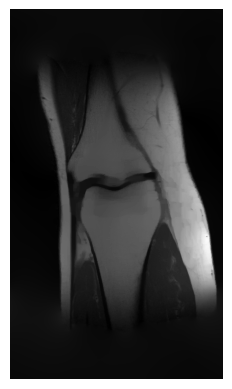

In [8]:
plot_image(x)

In [9]:
from operators.difference import Diff2D_FFT

D = Diff2D_FFT()

x = torch.randn(1, 1, 128, 128)

D(x).shape

torch.Size([2, 1, 128, 128])

In [45]:
# Now, try on a complex valued denoising problem:
from operators import Identity
E = Identity()
sigma = 0.1
y = gnd_truth + sigma*torch.randn_like(gnd_truth)

In [46]:
x, p, tol_reached = tvd_fista(y,        
        lam=0.1,    
        eta=8.0,    
        maxit = 500,
        tol = 1e-3,
        isotropic = True, 
        verbose = True)

Iteration 0: Maximum Residual is 0.100
Iteration 1: Maximum Residual is 0.054
Iteration 2: Maximum Residual is 0.044
Iteration 3: Maximum Residual is 0.037
Iteration 4: Maximum Residual is 0.032
Iteration 5: Maximum Residual is 0.027
Iteration 6: Maximum Residual is 0.025
Iteration 7: Maximum Residual is 0.022
Iteration 8: Maximum Residual is 0.020
Iteration 9: Maximum Residual is 0.019
Iteration 10: Maximum Residual is 0.017
Iteration 11: Maximum Residual is 0.016
Iteration 12: Maximum Residual is 0.016
Iteration 13: Maximum Residual is 0.014
Iteration 14: Maximum Residual is 0.014
Iteration 15: Maximum Residual is 0.013
Iteration 16: Maximum Residual is 0.013
Iteration 17: Maximum Residual is 0.013
Iteration 18: Maximum Residual is 0.012
Iteration 19: Maximum Residual is 0.012
Iteration 20: Maximum Residual is 0.012
Iteration 21: Maximum Residual is 0.011
Iteration 22: Maximum Residual is 0.011
Iteration 23: Maximum Residual is 0.010
Iteration 24: Maximum Residual is 0.011
Iteration 

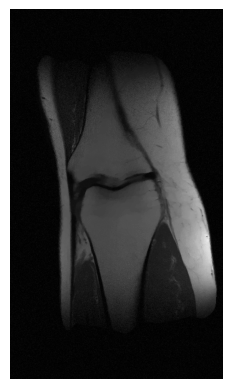

In [49]:
plot_image(x)

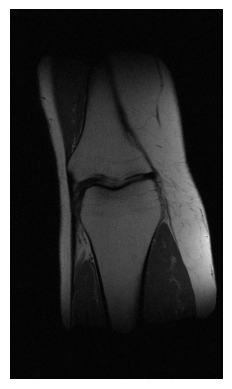

In [50]:
plot_image(y)

In [ ]:
tol_reached